In [4]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Iris
data = load_breast_cancer()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=30,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Explication locale (feature, poids):
[(np.str_('worst area'), -0.9211238680760753), (np.str_('worst concave points'), -0.7386685419423288), (np.str_('worst radius'), -0.5289505329737989), (np.str_('worst perimeter'), -0.5276965236018452), (np.str_('mean concave points'), -0.3316523808605127), (np.str_('area error'), -0.1359681868408548), (np.str_('mean texture'), -0.12548970601704845), (np.str_('worst concavity'), -0.11251482195160445), (np.str_('mean concavity'), -0.03872912513842733), (np.str_('mean area'), -0.0374511784511784), (np.str_('worst smoothness'), 0.0), (np.str_('mean radius'), 0.0), (np.str_('worst texture'), 0.0), (np.str_('mean perimeter'), 0.0), (np.str_('worst symmetry'), 0.0), (np.str_('mean smoothness'), 0.0), (np.str_('symmetry error'), 0.0), (np.str_('compactness error'), 0.0), (np.str_('mean symmetry'), 0.0), (np.str_('perimeter error'), 0.0), (np.str_('texture error'), 0.0), (np.str_(

In [6]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=30
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[(np.str_('worst area'), -0.06106013426176361), (np.str_('worst concave points'), -0.04489112602963899), (np.str_('worst perimeter'), -0.042321877594407656), (np.str_('worst radius'), -0.039327308233922983), (np.str_('mean concave points'), -0.030378859110491985), (np.str_('area error'), -0.028945079568184824), (np.str_('worst texture'), -0.025799824331458384), (np.str_('radius error'), -0.025741468157937986), (np.str_('mean texture'), -0.025050740088667978), (np.str_('mean concavity'), -0.022875213860589026), (np.str_('worst concavity'), -0.022541172757129406), (np.str_('mean area'), -0.013318117919565059), (np.str_('worst symmetry'), -0.010279841670707304), (np.str_('mean radius'), -0.009276762990768326), (np.str_('worst smoothness'), -0.00848342908015215), (np.str_('mean perimeter'), -0.006276557575646751), (np.str_('worst compactness'), -0.0056608427055970054), (np.str_('texture error'), -0.005240962507735707), (np.st

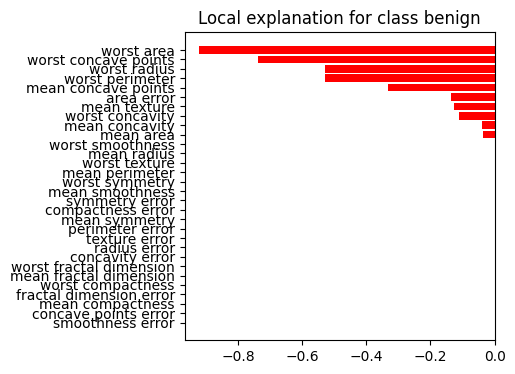

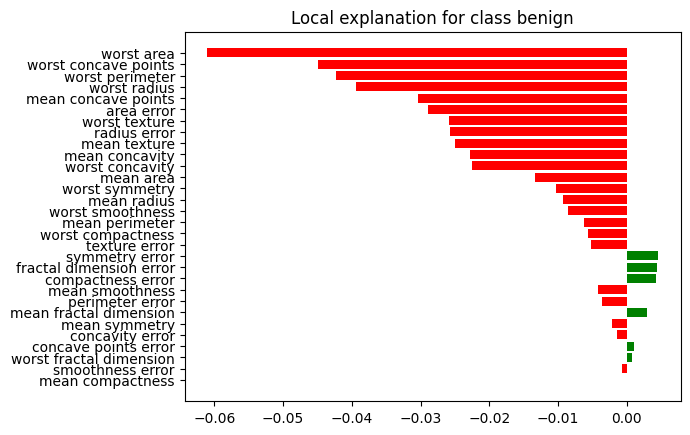

In [7]:
import matplotlib.pyplot as plt

exp.as_pyplot_figure()
plt.show()

exp_ridge.as_pyplot_figure()
plt.show()